In [43]:
# Librerías 

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import librosa
import librosa.display

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [44]:
# Configuración de la ruta para los archivos de audio

ruta_base = r"C:\Users\irwin\Downloads\Audios_Numeros"

In [45]:
# Cargar un archivo de audio y mostrar información básica

ruta_audio = r"C:\Users\irwin\Downloads\Audios_Numeros\1\Uno_Irwinng.ogg"

audio, sr = librosa.load(
    ruta_audio,
    sr=None
)

print("Frecuencia de muestreo:", sr)
print("Número de muestras:", len(audio))
print(
    "Duración:",
    round(len(audio) / sr, 2),
    "segundos"
)

Frecuencia de muestreo: 48000
Número de muestras: 124488
Duración: 2.59 segundos


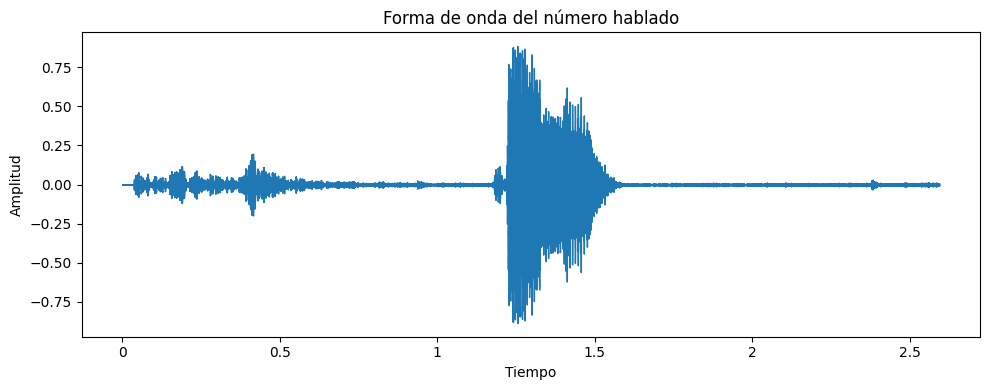

In [46]:
# Forma de onda 

plt.figure(figsize=(10, 4))

librosa.display.waveshow(
    audio,
    sr=sr
)

plt.title("Forma de onda del número hablado")
plt.xlabel("Tiempo")
plt.ylabel("Amplitud")

plt.tight_layout()
plt.show()

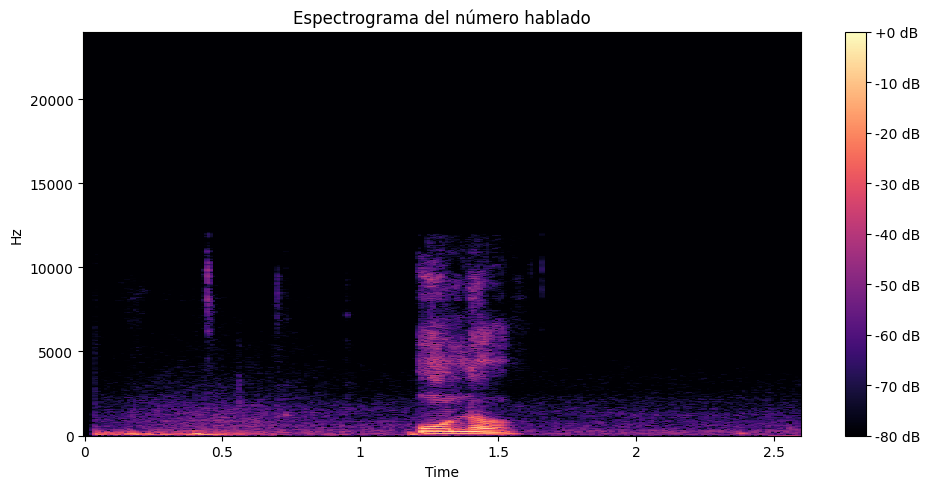

In [47]:
# Espectrograma

stft = librosa.stft(audio)

espectrograma_db = librosa.amplitude_to_db(
    np.abs(stft),
    ref=np.max
)

plt.figure(figsize=(10, 5))

librosa.display.specshow(
    espectrograma_db,
    sr=sr,
    x_axis="time",
    y_axis="hz"
)

plt.colorbar(
    format="%+2.0f dB"
)

plt.title("Espectrograma del número hablado")

plt.tight_layout()
plt.show()

Los Coeficientes Cepstrales en Frecuencia Mel son un conjunto de características numéricas que describen el contenido espectral de un audio.

Dimensiones de MFCC: (13, 244)


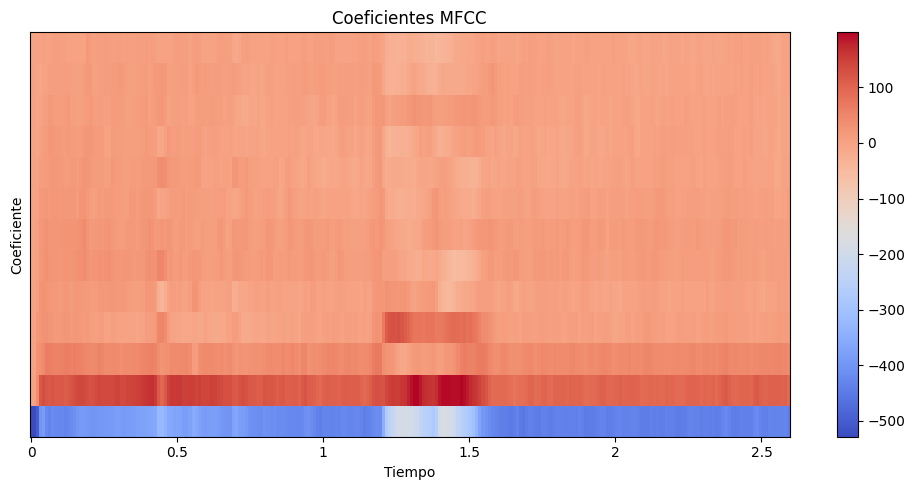

In [48]:
# Coeficientes MFCC

mfcc = librosa.feature.mfcc(
    y=audio,
    sr=sr,
    n_mfcc=13
)

print(
    "Dimensiones de MFCC:",
    mfcc.shape
)

plt.figure(figsize=(10, 5))

librosa.display.specshow(
    mfcc,
    sr=sr,
    x_axis="time"
)

plt.colorbar()

plt.title(
    "Coeficientes MFCC"
)

plt.xlabel("Tiempo")
plt.ylabel("Coeficiente")

plt.tight_layout()
plt.show()

In [49]:
# Función para extraer características de un archivo de audio

def extraer_caracteristicas(ruta):

    audio, sr = librosa.load(
        ruta,
        sr=22050,
        duration=3
    )

    # Normalizar volumen
    audio = librosa.util.normalize(audio)

    # MFCC
    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=sr,
        n_mfcc=13
    )

    mfcc_media = np.mean(
        mfcc,
        axis=1
    )

    mfcc_std = np.std(
        mfcc,
        axis=1
    )

    # Zero Crossing Rate
    zcr = librosa.feature.zero_crossing_rate(
        audio
    )

    zcr_media = np.mean(zcr)

    # Centroide espectral
    centroid = librosa.feature.spectral_centroid(
        y=audio,
        sr=sr
    )

    centroid_media = np.mean(
        centroid
    )

    # Rolloff espectral
    rolloff = librosa.feature.spectral_rolloff(
        y=audio,
        sr=sr,
        roll_percent=0.85
    )

    rolloff_media = np.mean(
        rolloff
    )

    # RMS
    rms = librosa.feature.rms(
        y=audio
    )

    rms_media = np.mean(
        rms
    )

    caracteristicas = np.concatenate([
        mfcc_media,
        mfcc_std,
        [
            zcr_media,
            centroid_media,
            rolloff_media,
            rms_media
        ]
    ])

    return caracteristicas

In [50]:
# Leer los archivos de audio

X = []
y = []

clases = sorted(
    os.listdir(ruta_base)
)

print(
    "Clases encontradas:",
    clases
)

for clase in clases:

    carpeta_clase = os.path.join(
        ruta_base,
        clase
    )

    if not os.path.isdir(
        carpeta_clase
    ):
        continue

    for archivo in os.listdir(
        carpeta_clase
    ):

        if archivo.lower().endswith(
            (
                ".wav",
                ".mp3",
                ".flac",
                ".ogg"
            )
        ):

            ruta = os.path.join(
                carpeta_clase,
                archivo
            )

            try:

                caracteristicas = (
                    extraer_caracteristicas(
                        ruta
                    )
                )

                X.append(
                    caracteristicas
                )

                y.append(
                    int(clase)
                )

            except Exception as e:

                print(
                    "Error en:",
                    ruta,
                    e
                )

Clases encontradas: ['1', '2']


In [51]:
# Convertir listas a arrays de NumPy

X = np.array(X)
y = np.array(y)

print(
    "Dimensiones X:",
    X.shape
)

print(
    "Dimensiones y:",
    y.shape
)

print(
    "Clases:",
    np.unique(y)
)

Dimensiones X: (20, 30)
Dimensiones y: (20,)
Clases: [1 2]


1    10
2    10
Name: count, dtype: int64

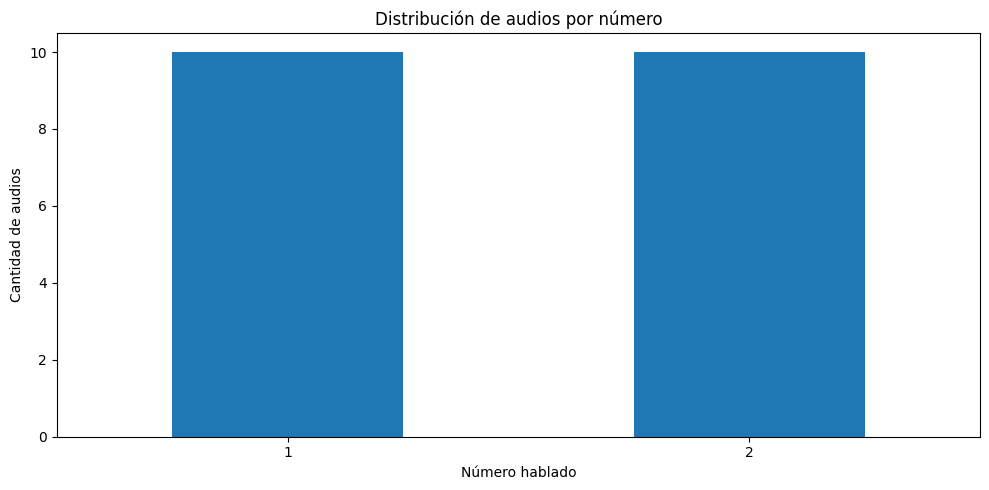

In [52]:
# Distribución de audios 

distribucion = pd.Series(
    y
).value_counts().sort_index()

display(
    distribucion
)

plt.figure(figsize=(10, 5))

distribucion.plot(
    kind="bar"
)

plt.title(
    "Distribución de audios por número"
)

plt.xlabel(
    "Número hablado"
)

plt.ylabel(
    "Cantidad de audios"
)

plt.xticks(
    rotation=0
)

plt.tight_layout()
plt.show()

In [53]:
# Dividir los datos en conjuntos de entrenamiento y prueba

X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.40,
        random_state=42,
        stratify=y
    )
)

print(
    "Entrenamiento:",
    X_train.shape
)

print(
    "Prueba:",
    X_test.shape
)

Entrenamiento: (12, 30)
Prueba: (8, 30)


In [54]:
# Modelo

modelo = Pipeline([
    (
        "escalador",
        StandardScaler()
    ),
    (
        "modelo",
        RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            random_state=42
        )
    )
])

In [55]:
# Entrenar el modelo

modelo.fit(
    X_train,
    y_train
)

print(
    "Modelo entrenado correctamente"
)

Modelo entrenado correctamente


In [56]:
# Predicciones en el conjunto de prueba

predicciones = modelo.predict(
    X_test
)

accuracy = accuracy_score(
    y_test,
    predicciones
)

print(
    "Accuracy:",
    round(
        accuracy * 100,
        2
    ),
    "%"
)

Accuracy: 50.0 %


In [57]:
# Clasificación 

print(
    classification_report(
        y_test,
        predicciones,
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           1     0.5000    0.7500    0.6000         4
           2     0.5000    0.2500    0.3333         4

    accuracy                         0.5000         8
   macro avg     0.5000    0.5000    0.4667         8
weighted avg     0.5000    0.5000    0.4667         8



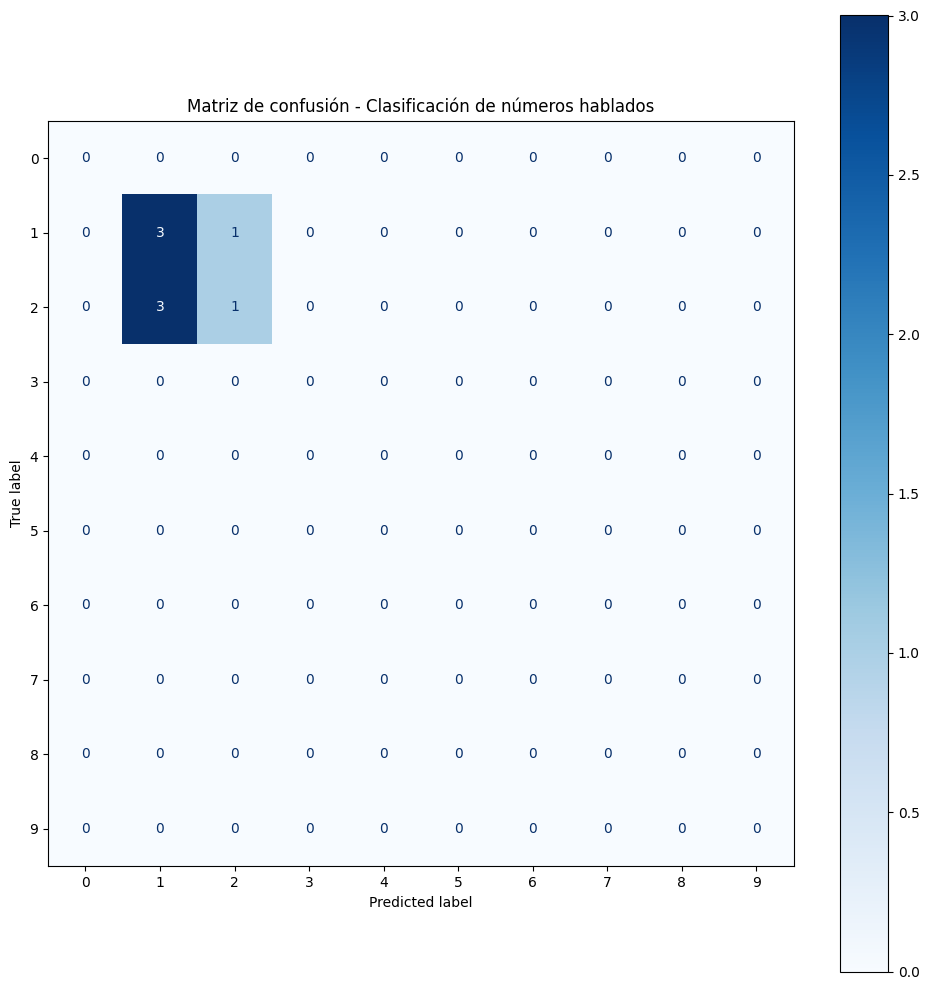

In [58]:
# Matriz de confusión

clases_numeros = list(
    range(10)
)

matriz = confusion_matrix(
    y_test,
    predicciones,
    labels=clases_numeros
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=clases_numeros
)

fig, ax = plt.subplots(
    figsize=(10, 10)
)

disp.plot(
    ax=ax,
    cmap="Blues"
)

plt.title(
    "Matriz de confusión - Clasificación de números hablados"
)

plt.tight_layout()
plt.show()

In [59]:
# Clasificar un nuevo audio

ruta_nueva = (
    r"C:\Users\irwin\Downloads\numero_nuevo.ogg"
)

caracteristicas = (
    extraer_caracteristicas(
        ruta_nueva
    )
)

entrada = caracteristicas.reshape(
    1,
    -1
)

prediccion = modelo.predict(
    entrada
)

print(
    "Número reconocido:",
    prediccion[0]
)

Número reconocido: 1


In [61]:
# Clasificar un nuevo audio

ruta_nueva = (
    r"C:\Users\irwin\Downloads\numero_nuevo_1.ogg"
)

caracteristicas = (
    extraer_caracteristicas(
        ruta_nueva
    )
)

entrada = caracteristicas.reshape(
    1,
    -1
)

prediccion = modelo.predict(
    entrada
)

print(
    "Número reconocido:",
    prediccion[0]
)

Número reconocido: 2
